# Load & Check Data

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import streamlit as st
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


def load_data():
    df = pd.read_csv("C:/Users/shiva/OneDrive/Desktop/AI_Predictive_Analytics/data/superstore_sales.csv", encoding='latin1')
    return df

df = load_data()

st.write("✅ Data Loaded Successfully!")
st.write("🧾 Columns in your dataset:", df.columns)


print("✅ Columns in your dataset:")
print(df.columns.tolist())

2025-11-01 16:39:12.222 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-01 16:39:12.223 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-01 16:39:12.224 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-01 16:39:12.224 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-01 16:39:12.225 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-01 16:39:12.226 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-01 16:39:12.226 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-01 16:39:12.227 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

✅ Columns in your dataset:
['Customer ID', 'Customer Name', 'Last Name', 'Date of Birth', 'Sales', 'Year', 'Outlet Type', 'City Type', 'Category of Goods', 'Region', 'Country', 'Segment', 'Sales Date', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'State', 'Postal Code', 'Product ID', 'Sub-Category', 'Product Name', 'Quantity', 'Discount', 'Profit']


# Clean the Data

In [11]:

print(df.isnull().sum())

# Drop rows with missing critical values
df.dropna(subset=['Sales', 'Profit'], inplace=True)

# Convert date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Group by correct category column
cat_sales = df.groupby('Category of Goods')['Sales'].sum().sort_values(ascending=False)

# Plot
fig = px.bar(cat_sales,
             x=cat_sales.index,
             y=cat_sales.values,
             title="📊 Total Sales by Category of Goods",
             text_auto=True,
             color=cat_sales.values,
             color_continuous_scale="viridis")

st.plotly_chart(fig)
fig = px.bar(cat_sales, x=cat_sales.index, y=cat_sales.values, title="Sales by Category", text_auto=True)
st.plotly_chart(fig)
# Remove duplicates
df.drop_duplicates(inplace=True)

print("✅ Data Cleaned!")


Customer ID          0
Customer Name        0
Last Name            0
Date of Birth        0
Sales                0
Year                 0
Outlet Type          0
City Type            0
Category of Goods    0
Region               0
Country              0
Segment              0
Sales Date           0
Order ID             0
Order Date           0
Ship Date            0
Ship Mode            0
State                0
Postal Code          0
Product ID           0
Sub-Category         0
Product Name         0
Quantity             0
Discount             0
Profit               0
dtype: int64


2025-11-01 16:40:42.154 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-01 16:40:42.155 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-01 16:40:42.157 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-01 16:40:42.158 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-01 16:40:42.158 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-01 16:40:42.185 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-01 16:40:42.186 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-11-01 16:40:42.186 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

✅ Data Cleaned!


# Exploratory Data Analysis

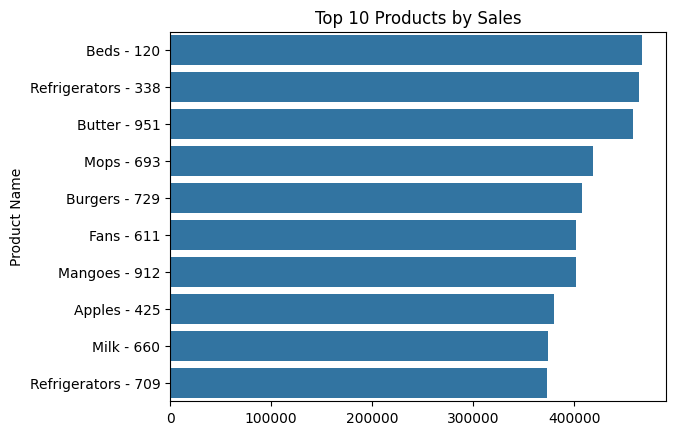

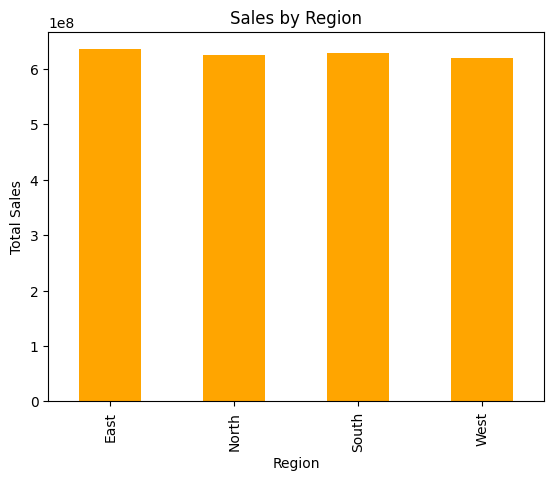

In [12]:
# Top 10 products by sales
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Products by Sales")
plt.show()

# Sales by Region
region_sales = df.groupby('Region')['Sales'].sum()
region_sales.plot(kind='bar', color='orange')
plt.title("Sales by Region")
plt.ylabel("Total Sales")
plt.show()


# Machine Learning Model (Predict Future Sales)

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Aggregate monthly sales
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum().reset_index()
monthly_sales['Order Date'] = monthly_sales['Order Date'].dt.to_timestamp()

# Features
monthly_sales['Month'] = monthly_sales['Order Date'].dt.month
monthly_sales['Year'] = monthly_sales['Order Date'].dt.year

X = monthly_sales[['Month', 'Year']]
y = monthly_sales['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("📈 R2 Score:", r2_score(y_test, y_pred))
print("📉 RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


📈 R2 Score: 0.02664527149817708
📉 RMSE: 1032524.9992932853
